# Process Dataset — SageMaker-ready

Encoding, scaling and hierarchical clustering on `full_dataset.csv`.

This notebook is designed to run unchanged in:
- A local Jupyter environment.
- Amazon SageMaker Studio (Data Science / Python 3 image).
- A classic SageMaker Notebook Instance (`conda_python3` kernel).

Configuration knobs at the top of the notebook let you switch between a local path and an S3 prefix without touching the pipeline.

In [1]:
# INPUT_CSV_NAME = os.environ.get("INPUT_CSV", "full_dataset_encoded.csv")
# INPUT_CSV = f"{INPUT_CSV_NAME}"
LABELLED_OUT = f"full_dataset_hc_labels.csv"
PROFILE_OUT = f"full_dataset_hc_profile.csv"
SWEEP_OUT = f"hc_sweep.csv"
DENDROGRAM_OUT = f"hc_dendrogram.png"

In [2]:
import logging
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist

In [3]:
def plot_dendrogram(Z: np.ndarray, k: int, out_path: str) -> None:
    """Truncated dendrogram showing the last 30 merges, with the cut for k."""
    fig, ax = plt.subplots(figsize=(12, 5))
    dendrogram(
        Z,
        truncate_mode="lastp",
        p=30,
        show_leaf_counts=True,
        leaf_rotation=90,
        ax=ax,
    )
    # Horizontal line at the height that produces k clusters
    if Z.shape[0] + 1 > k:
        # Z is sorted ascending by distance; the cut height for k clusters is
        # between Z[-k, 2] and Z[-k+1, 2].
        cut_height = Z[-k + 1, 2] if k > 1 else Z[-1, 2] * 1.1
        ax.axhline(cut_height, color="red", linestyle="--",
                   label=f"cut for k={k}")
        ax.legend()
    ax.set_title("Hierarchical clustering — Ward linkage (sample dendrogram)")
    ax.set_xlabel("Cluster size (leaves)")
    ax.set_ylabel("Ward distance")
    fig.tight_layout()
    fig.savefig(out_path, dpi=120)
    plt.close(fig)
    log.info("Saved dendrogram: %s", out_path)


def sweep_k(
    Z: np.ndarray,
    X_sample: np.ndarray,
    k_candidates: list[int],
    random_state: int,
) -> pd.DataFrame:
    """For each k, compute silhouette on the sample and cluster sizes."""
    rows = []
    for k in k_candidates:
        labels_k = fcluster(Z, t=k, criterion="maxclust")
        unique = np.unique(labels_k)
        if len(unique) > 1:
            sil = float(silhouette_score(
                X_sample, labels_k,
                sample_size=min(2000, len(X_sample)),
                random_state=random_state,
            ))
        else:
            sil = float("nan")
        # bincount is 0-indexed; fcluster labels start at 1
        sizes = np.bincount(labels_k)[1:].tolist()
        log.info("k=%d  silhouette=%.3f  sizes=%s", k, sil, sizes)
        rows.append({"k": k, "silhouette": sil, "sizes": sizes})
    return pd.DataFrame(rows)


def label_full_dataset(
    X: np.ndarray,
    k: int,
    total_mem_gb: float,
) -> np.ndarray:
    """Cluster every row. Falls back to a k-NN connectivity graph if the
    dense distance matrix would bust the RAM budget."""
    n = X.shape[0]
    dense_bytes = n * n * 4  # float32 distance matrix
    budget_bytes = 0.5 * total_mem_gb * 1e9

    if dense_bytes < budget_bytes:
        log.info("Clustering %d rows with dense Ward (~%.1f GB distance matrix)",
                 n, dense_bytes / 1e9)
        t0 = time.time()
        agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = agg.fit_predict(X)
        log.info("Dense Ward done in %.1fs", time.time() - t0)
    else:
        log.info("Dense distance matrix (%.1f GB) exceeds budget. "
                 "Using k-NN connectivity-constrained Ward.",
                 dense_bytes / 1e9)
        t0 = time.time()
        conn = kneighbors_graph(X, n_neighbors=30, include_self=False, n_jobs=-1)
        agg = AgglomerativeClustering(n_clusters=k, linkage="ward",
                                      connectivity=conn)
        labels = agg.fit_predict(X)
        log.info("Connectivity-constrained Ward done in %.1fs",
                 time.time() - t0)

    log.info("Full-dataset cluster sizes: %s", np.bincount(labels).tolist())
    return labels


def build_profile(
    df: pd.DataFrame,
    labels: np.ndarray,
) -> pd.DataFrame:
    """Mean of numeric + bool features and dominant category per cluster."""
    df_labelled = df.copy()
    df_labelled["hc_cluster"] = labels

    numeric_present = [c for c in NUMERIC_COLS if c in df_labelled.columns]
    bool_present = [c for c in BOOL_COLS if c in df_labelled.columns]

    profile = (
        df_labelled
        .groupby("hc_cluster")[numeric_present + bool_present]
        .mean(numeric_only=True)
        .round(2)
    )
    profile["count"] = df_labelled.groupby("hc_cluster").size()

    # Dominant category per cluster for any leftover string columns
    cat_cols = df_labelled.select_dtypes(include=["object"]).columns.tolist()
    cat_cols = [c for c in cat_cols if c not in ID_COLS + ["hc_cluster"]]
    if cat_cols:
        dominant = {
            col: df_labelled.groupby("hc_cluster")[col]
                            .agg(lambda s: s.value_counts().index[0])
            for col in cat_cols
        }
        profile = profile.join(pd.DataFrame(dominant))

    return df_labelled, profile


def choose_k_from_sweep(sweep_df: pd.DataFrame) -> int:
    """Pick k that maximises silhouette while keeping the smallest cluster
    at >= 2 % of the data."""
    eligible = sweep_df.copy()
    eligible["min_size"] = eligible["sizes"].apply(min)
    eligible["total"] = eligible["sizes"].apply(sum)
    eligible["min_frac"] = eligible["min_size"] / eligible["total"]
    eligible = eligible[eligible["min_frac"] >= 0.02]
    if eligible.empty:
        # fall back to raw max silhouette
        eligible = sweep_df
    best = eligible.sort_values("silhouette", ascending=False).iloc[0]
    log.info("Auto-picked k=%d (silhouette=%.3f, min_frac=%.1f%%)",
             int(best["k"]), best["silhouette"],
             100 * min(best["sizes"]) / sum(best["sizes"]))
    return int(best["k"])


def pick_sample_size(n_rows: int, max_sample: int = 5000) -> int:
    """Cap the sample so `pdist` fits in ~12 % of RAM."""
    try:
        import psutil
        total_mem_gb = psutil.virtual_memory().total / 1e9
    except Exception:
        total_mem_gb = 4.0

    budget_bytes = 0.12 * total_mem_gb * 1e9
    # n*(n-1)/2 * 4 bytes <= budget  ->  n <= sqrt(budget / 2)
    n_by_mem = int(np.sqrt(budget_bytes / 2))
    sample = int(min(max_sample, n_by_mem, n_rows))
    log.info("Detected ~%.1f GB RAM -> sample size for dendrogram = %d",
             total_mem_gb, sample)
    return sample

## 0. Environment bootstrap

Installs/upgrades the libraries the pipeline needs. `%pip` (not `!pip`) is used so the install happens inside the active kernel — the recommended pattern on SageMaker. Running twice is safe; pip will no-op if everything is already satisfied.

In [4]:
%pip install -q --upgrade \
    "pandas>=2.0" \
    "numpy>=1.24" \
    "scikit-learn>=1.3" \
    "scipy>=1.10" \
    "matplotlib>=3.7" \
    "joblib>=1.3" \
    "psutil" \
    "s3fs" \
    "pyarrow"

Note: you may need to restart the kernel to use updated packages.


In [5]:


# Logging — shows up cleanly in the Studio cell output and CloudWatch
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
    stream=sys.stdout,
    force=True,
)
log = logging.getLogger("process_dataset")

pd.set_option("display.max_columns", 100)
matplotlib.rcParams["figure.dpi"] = 110

log.info("python %s", sys.version.split()[0])
log.info("pandas %s | numpy %s", pd.__version__, np.__version__)
import sklearn, scipy
log.info("sklearn %s | scipy %s", sklearn.__version__, scipy.__version__)

16:45:59 | INFO | python 3.11.11
16:45:59 | INFO | pandas 3.0.2 | numpy 2.4.4
16:45:59 | INFO | sklearn 1.8.0 | scipy 1.17.1


## 1. Paths & configuration

Resolves input/output locations. Priority order:
1. Env var `DATA_DIR` (handy for SageMaker Processing / Training jobs where data lands at `/opt/ml/processing/input`).
2. S3 prefix via `S3_DATA_URI` (e.g. `s3://my-bucket/datathon/ds/`).
3. Default: the directory this notebook lives in.

In [6]:
RANDOM_STATE = 42

# Resolve the notebook's own directory in a way that works in Studio too.
try:
    NB_DIR = Path(__file__).resolve().parent  # if exported to .py
except NameError:
    NB_DIR = Path(os.getcwd()).resolve()

S3_DATA_URI = os.environ.get("S3_DATA_URI", "").rstrip("/")
DATA_DIR = os.environ.get("DATA_DIR", str(NB_DIR))

if S3_DATA_URI:
    INPUT_BASE = S3_DATA_URI
    OUTPUT_BASE = os.environ.get("S3_OUTPUT_URI", S3_DATA_URI).rstrip("/")
    log.info("Using S3 data path: %s", INPUT_BASE)
else:
    INPUT_BASE = str(Path(DATA_DIR))
    OUTPUT_BASE = str(Path(DATA_DIR))
    log.info("Using local data path: %s", INPUT_BASE)

INPUT_CSV = f"full_dataset_encoded.csv"
ENCODED_OUT = f"{OUTPUT_BASE}/full_dataset_encoded.csv"
LABELLED_OUT = f"{OUTPUT_BASE}/full_dataset_hc_labels.csv"
PROFILE_OUT = f"{OUTPUT_BASE}/full_dataset_hc_profile.csv"
log.info("Input : %s", INPUT_CSV)
log.info("Output: %s", OUTPUT_BASE)

16:45:59 | INFO | Using local data path: /mnt/custom-file-systems/s3/shared
16:45:59 | INFO | Input : full_dataset_encoded.csv
16:45:59 | INFO | Output: /mnt/custom-file-systems/s3/shared


## 2. Load the dataset

`pd.read_csv` works transparently with `s3://` URIs when `s3fs` is installed and the execution role has `s3:GetObject` on the bucket.

In [7]:
t0 = time.time()
df = pd.read_csv(INPUT_CSV)
log.info("Loaded %s rows x %s cols in %.1fs", *df.shape, time.time() - t0)

df.dtypes
# df.drop('')

16:45:59 | INFO | Loaded 15025 rows x 52 cols in 0.2s


user_id                                                                            str
edad                                                                             int64
ingreso_mensual_mxn                                                              int64
antiguedad_dias                                                                  int64
es_hey_pro                                                                       int64
nomina_domiciliada                                                                bool
score_buro                                                                       int64
dias_desde_ultimo_login                                                          int64
satisfaccion_1_10                                                              float64
recibe_remesas                                                                   int64
tiene_seguro                                                                     int64
num_productos_activos                      

In [8]:
# Fill NaNs, then cast to int
df["num_no_procesadas"] = df["num_no_procesadas"].fillna(0).astype(int)
df["satisfaccion_1_10"] = df["satisfaccion_1_10"].fillna(df["satisfaccion_1_10"].median()).astype(int)

# Verify
print(df[["satisfaccion_1_10", "num_no_procesadas"]].dtypes)


satisfaccion_1_10    int64
num_no_procesadas    int64
dtype: object


In [9]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler

df_model = df.copy()

# 1. Identifiers to exclude from features
id_cols = ["user_id"]

# 2. Cast booleans to int so they act like dummies
bool_cols = df_model.select_dtypes(include="bool").columns.tolist()
df_model[bool_cols] = df_model[bool_cols].astype(int)

# 3. True continuous features (everything else is already 0/1 dummies)
continuous_cols = [
    "edad",
    "ingreso_mensual_mxn",
    "antiguedad_dias",
    "nomina_domiciliada",          # keep only if not binary; drop if it's 0/1
    "score_buro",
    "dias_desde_ultimo_login",
    "satisfaccion_1_10",
    "num_productos_activos",
    "num_no_procesadas",
    "num_transacciones",
]


# Which columns have NaNs and how many?
na_counts = df_model[continuous_cols].isna().sum()
print(na_counts[na_counts > 0].sort_values(ascending=False))
print("Rows with any NaN:", df_model[continuous_cols].isna().any(axis=1).sum())
print("Total rows:", len(df_model))


Series([], dtype: int64)
Rows with any NaN: 0
Total rows: 15025


## 3. Column groups

## 4. Clean, impute, encode

In [10]:



# Keep only those actually present
continuous_cols = [c for c in continuous_cols if c in df_model.columns]

# 4. Sanity checks
assert df_model[continuous_cols].isna().sum().sum() == 0, "NaNs in continuous cols"
iqr = df_model[continuous_cols].quantile(0.75) - df_model[continuous_cols].quantile(0.25)
zero_iqr = iqr[iqr == 0].index.tolist()
if zero_iqr:
    print("Dropping zero-IQR cols:", zero_iqr)
    continuous_cols = [c for c in continuous_cols if c not in zero_iqr]




## 5. Scale and build the feature matrix

`float32` halves memory usage vs. `float64` with no meaningful loss in Ward distance quality.

In [11]:
# 5. Scale only the continuous ones
scaler = RobustScaler()
df_model[continuous_cols] = scaler.fit_transform(df_model[continuous_cols])

# 6. Build feature matrix
feature_cols = [c for c in df_model.columns if c not in id_cols]
X = df_model[feature_cols].to_numpy(dtype=float)

print("Feature matrix shape:", X.shape)
print("Continuous (scaled):", len(continuous_cols))
print("Binary/dummy (unscaled):", len(feature_cols) - len(continuous_cols))
X

Feature matrix shape: (15025, 51)
Continuous (scaled): 10
Binary/dummy (unscaled): 41


array([[-0.9375    ,  0.02380952,  0.69152542, ...,  1.        ,
         0.        ,  0.        ],
       [-1.125     , -0.23809524,  0.52881356, ...,  0.        ,
         0.        ,  0.        ],
       [-0.8125    , -0.47619048,  0.26214689, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.625     , -0.21428571, -0.30621469, ...,  0.        ,
         0.        ,  1.        ],
       [-0.5625    , -0.92857143, -0.5740113 , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.6875    ,  0.47619048, -0.75819209, ...,  0.        ,
         0.        ,  1.        ]], shape=(15025, 51))

## 6. Choose a sample size that fits in RAM

`scipy.cluster.hierarchy.linkage` needs an `O(n²)` condensed distance matrix (≈`4·n·(n-1)/2` bytes in float32). On a `ml.t3.medium` (≈4 GB) we cap the sample so the pdist matrix stays under ~500 MB. On bigger instances we use up to 5k rows.

In [12]:
max_sample = 3000
n_rows = X.shape[0]
try:
    import psutil
    total_mem_gb = psutil.virtual_memory().total / 1e9
except Exception:
    total_mem_gb = 4.0

budget_bytes = 0.12 * total_mem_gb * 1e9
# n*(n-1)/2 * 4 bytes <= budget  ->  n <= sqrt(budget / 2)
n_by_mem = int(np.sqrt(budget_bytes / 2))
sample = int(min(max_sample, n_by_mem, n_rows))
log.info("Detected ~%.1f GB RAM -> sample size for dendrogram = %d",
         total_mem_gb, sample)

16:45:59 | INFO | Detected ~4.0 GB RAM -> sample size for dendrogram = 3000


## 7. Dendrogram (sample) + cophenetic correlation

In [13]:
# Sample for linkage + dendrogram
sample_size = pick_sample_size(X.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(X.shape[0], size=sample_size, replace=False)
X_sample = X[sample_idx]

16:45:59 | INFO | Detected ~4.0 GB RAM -> sample size for dendrogram = 5000


In [ ]:
# Ward linkage on the sample
t0 = time.time()
Z = linkage(X_sample, method="ward")
log.info("Sample linkage done in %.1fs", time.time() - t0)

coph_corr, _ = cophenet(Z, pdist(X_sample))
log.info("Cophenetic correlation (sample): %.4f", coph_corr)

# Sweep k on the sample (cheap)
sweep_df = sweep_k(Z, X_sample, k_candidates=[2, 3, 4, 5, 6, 7, 8],
                   random_state=RANDOM_STATE)
sweep_df.to_csv(SWEEP_OUT, index=False)
log.info("Saved sweep: %s", SWEEP_OUT)

# Choose k: env var wins, otherwise pick from sweep
env_k = os.environ.get("K_FINAL")
if env_k:
    k_final = int(env_k)
    log.info("Using K_FINAL=%d from environment", k_final)
else:
    k_final = choose_k_from_sweep(sweep_df)

# Dendrogram with the cut line
plot_dendrogram(Z, k_final, DENDROGRAM_OUT)

# Label the full dataset
try:
    import psutil
    total_mem_gb = psutil.virtual_memory().total / 1e9
except Exception:
    total_mem_gb = 4.0
labels_full = label_full_dataset(X, k_final, total_mem_gb)

# Build and save profile
df_labelled, profile = build_profile(df, labels_full)

df_labelled.to_csv(LABELLED_OUT, index=False)
profile.to_csv(PROFILE_OUT)
log.info("Saved labelled dataset: %s  %s", LABELLED_OUT, df_labelled.shape)
log.info("Saved profile: %s", PROFILE_OUT)

log.info("Done. k=%d, rows=%d, features=%d",
         k_final, X.shape[0], X.shape[1])

16:46:01 | INFO | Sample linkage done in 1.5s
16:46:02 | INFO | Cophenetic correlation (sample): 0.8805
16:46:02 | INFO | k=2  silhouette=0.601  sizes=[341, 4659]
16:46:02 | INFO | k=3  silhouette=0.191  sizes=[341, 3692, 967]
16:46:02 | INFO | k=4  silhouette=0.145  sizes=[341, 3692, 213, 754]
16:46:02 | INFO | k=5  silhouette=0.117  sizes=[341, 1340, 2352, 213, 754]
16:46:02 | INFO | k=6  silhouette=0.100  sizes=[341, 1340, 984, 1368, 213, 754]
16:46:02 | INFO | k=7  silhouette=0.089  sizes=[180, 161, 1340, 984, 1368, 213, 754]
16:46:02 | INFO | k=8  silhouette=0.085  sizes=[180, 161, 1340, 984, 685, 683, 213, 754]
16:46:03 | INFO | Saved sweep: hc_sweep.csv
16:46:03 | INFO | Auto-picked k=2 (silhouette=0.601, min_frac=6.8%)
16:46:03 | INFO | Saved dendrogram: hc_dendrogram.png
16:46:03 | INFO | Clustering 15025 rows with dense Ward (~0.9 GB distance matrix)


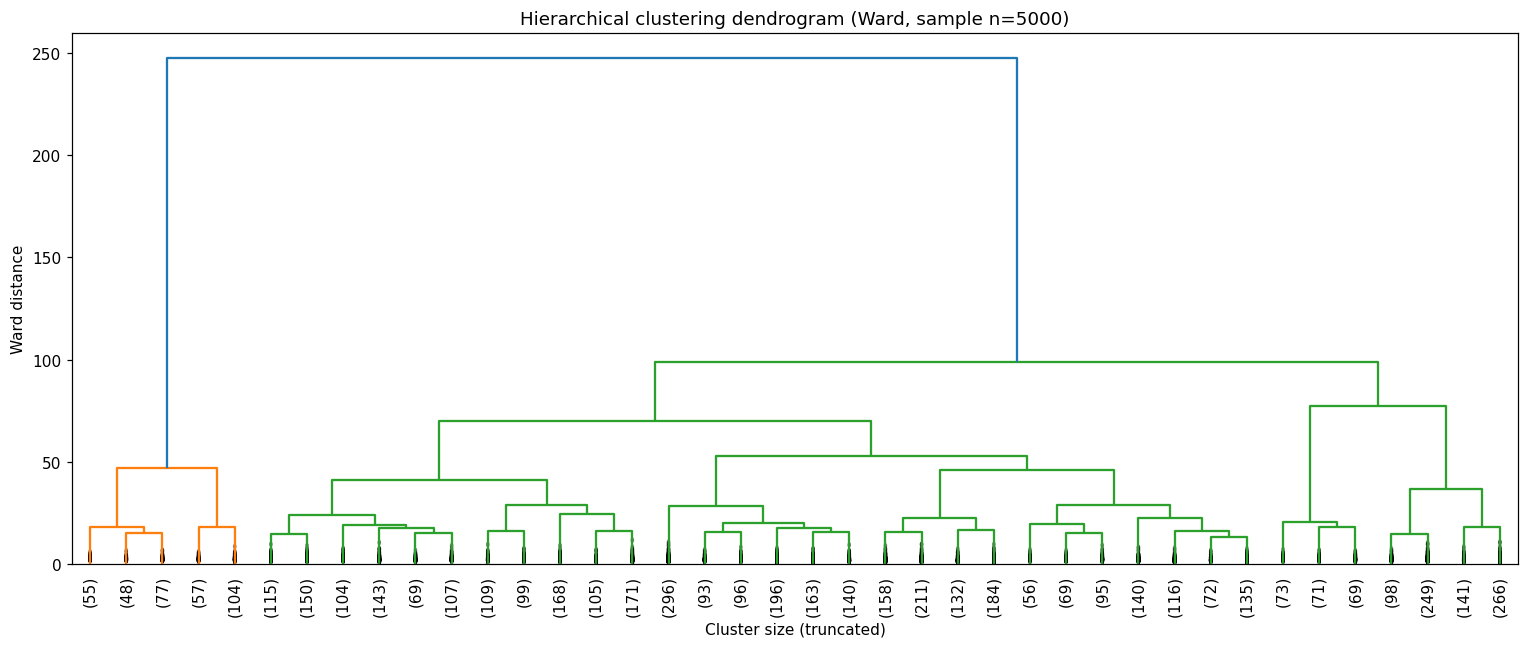

In [19]:
fig = plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=40,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
)
plt.title(f"Hierarchical clustering dendrogram (Ward, sample n={SAMPLE_SIZE})")
plt.xlabel("Cluster size (truncated)")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()


## 8. Pick `k` with a silhouette sweep on the sample

In [20]:
candidate_ks = [2, 3, 4, 5, 6, 7, 8]
scores = {}
for k in candidate_ks:
    labels_k = fcluster(Z, t=k, criterion="maxclust")
    if len(np.unique(labels_k)) < 2:
        continue
    s = silhouette_score(X_sample, labels_k, metric="euclidean")
    scores[k] = float(s)
    log.info("k=%d  silhouette=%.4f", k, s)

best_k = max(scores, key=scores.get)
log.info("Best k by silhouette on sample: %d", best_k)

09:28:37 | INFO | k=2  silhouette=0.5971
09:28:37 | INFO | k=3  silhouette=0.1912
09:28:38 | INFO | k=4  silhouette=0.1411
09:28:38 | INFO | k=5  silhouette=0.1144
09:28:38 | INFO | k=6  silhouette=0.0967
09:28:39 | INFO | k=7  silhouette=0.0865
09:28:39 | INFO | k=8  silhouette=0.0833
09:28:39 | INFO | Best k by silhouette on sample: 2


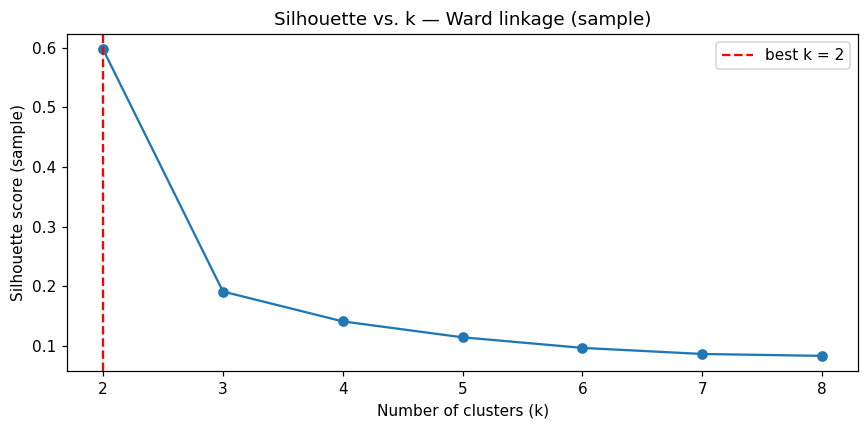

In [21]:
fig = plt.figure(figsize=(8, 4))
plt.plot(list(scores.keys()), list(scores.values()), marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score (sample)")
plt.title("Silhouette vs. k — Ward linkage (sample)")
plt.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

## 9. Fit on the full dataset with a connectivity constraint

Unconstrained Ward on 15k rows builds the full distance tree in memory. Passing a sparse k-NN `connectivity` graph tells scikit-learn to only consider local merges, which cuts memory from `O(n²)` to `O(n·k)` and usually runs much faster on a SageMaker CPU instance. Silhouette is computed on a 5k subsample because the full one is `O(n²)`.

In [22]:
N_CLUSTERS = best_k  # override here if the dendrogram suggests differently

t0 = time.time()
connectivity = kneighbors_graph(
    X,
    n_neighbors=30,
    include_self=False,
    n_jobs=-1,
)
# Symmetrize — required for Ward when using a connectivity matrix
connectivity = 0.5 * (connectivity + connectivity.T)
log.info("k-NN connectivity built in %.1fs (nnz=%d)", time.time() - t0, connectivity.nnz)

t0 = time.time()
agg = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage="ward",
    connectivity=connectivity,
)
labels = agg.fit_predict(X)
log.info("AgglomerativeClustering fit in %.1fs", time.time() - t0)

sizes = pd.Series(labels).value_counts().sort_index()
log.info("Cluster sizes:\n%s", sizes.to_string())

09:28:53 | INFO | k-NN connectivity built in 1.7s (nnz=627494)
09:29:04 | INFO | AgglomerativeClustering fit in 10.3s
09:29:04 | INFO | Cluster sizes:
0    13842
1     1183


In [23]:
eval_idx = rng.choice(X.shape[0], size=min(5000, X.shape[0]), replace=False)
sil_full = silhouette_score(X[eval_idx], labels[eval_idx], metric="euclidean", n_jobs=-1)
log.info("Silhouette (full model, 5k sample): %.4f", sil_full)

09:29:22 | INFO | Silhouette (full model, 5k sample): 0.5905


## 10. Attach labels & profile clusters

In [24]:
df_labelled = df.copy()
df_labelled["hc_cluster"] = labels

profile = (
    df_labelled.groupby("hc_cluster")[numeric_cols + bool_cols]
    .mean(numeric_only=True)
    .round(2)
)
profile["count"] = df_labelled.groupby("hc_cluster").size()
profile

,edad,ingreso_mensual_mxn,antiguedad_dias,score_buro,dias_desde_ultimo_login,satisfaccion_1_10,num_productos_activos,num_no_procesadas,num_transacciones,es_hey_pro,recibe_remesas,tiene_seguro,count
hc_cluster,,,,,,,,,,,,,
0,36.90,30640.66,937.80,624.95,9.33,7.66,2.36,1.90,57.12,0.52,0.08,0.28,13842
1,40.56,19883.35,903.65,542.42,129.18,5.61,0.71,0.26,9.90,0.08,0.08,0.18,1183


In [27]:
dominant = {}
for col in categorical_cols:
    dominant[col] = (
        df_labelled.groupby("hc_cluster")[col]
        .agg(lambda s: s.value_counts().index[0])
    )
dominant_df = pd.DataFrame(dominant)
dominant_df

""


## 11. Save outputs

Writes support both local paths and `s3://` URIs. On SageMaker Processing jobs point `S3_OUTPUT_URI` (or `DATA_DIR=/opt/ml/processing/output`) to the expected output channel.

In [ ]:
df_encoded.to_csv(ENCODED_OUT, index=False)
df_labelled.to_csv(LABELLED_OUT, index=False)
profile.join(dominant_df).to_csv(PROFILE_OUT)

log.info("Saved: %s  %s", ENCODED_OUT, df_encoded.shape)
log.info("Saved: %s  %s", LABELLED_OUT, df_labelled.shape)
log.info("Saved: %s  (profile)", PROFILE_OUT)